#Analisis predictivo de fallas en arquitecturas OpenStack

##Introducción: 

En el panorama actual de la tecnología, la gestión de la infraestructura en la nube se ha vuelto demasiado compleja. Plataformas distribuidas como OpenStack permiten a las organizaciones desplegar y gestionar enormes entornos de nube, orquestando miles de máquinas virtuales, redes y sistemas de almacenamiento simultáneamente. Sin embargo, esta escala trae consigo un reto operativo significativo: cuando ocurre una falla en algún microservicio, identificar la causa raíz entre millones de líneas de logs (registros) y métricas es un proceso lento y altamente complejo para los operadores humanos.

Es para resolver este problema que surge el concepto de AIOps.

AIOps (Inteligencia Artificial para Operaciones de TI) se define como la aplicación de técnicas de ciencia de datos, estadística avanzada y aprendizaje automático (machine learning) a los grandes volúmenes de datos generados por las operaciones tecnológicas. Su propósito principal es mejorar y automatizar el monitoreo de la infraestructura, permitiendo detectar anomalías en tiempo real, predecir caídas antes de que ocurran y acelerar la resolución de problemas (pasar de una postura reactiva a una proactiva).

El presente proyecto se enmarca dentro de esta filosofía. A través del análisis de un conjunto de datos (dataset) proveniente de un entorno OpenStack sometido a inyecciones de fallas controladas, utilizaremos herramientas de estadística descriptiva e inferencial para entender cómo se comportan los distintos componentes del sistema bajo estrés. El objetivo es descubrir patrones, evaluar la propagación de errores y extraer conclusiones fundamentadas en los datos que demuestren el valor del análisis cuantitativo en la mejora de la confiabilidad de los servicios en la nube.

Teniendo esto en cuenta, podemos plantearnos las siguientes preguntas

1. Al analizar diferentes escenarios, ¿qué tipo de falla inyectada (por ejemplo, estrés de CPU vs. pérdida de paquetes en la red) genera un impacto más visible o propaga más errores a través de los distintos componentes del sistema (Nova, Neutron, Cinder)

2. ¿Existe una diferencia estadísticamente significativa en los tiempos de respuesta (latencia) de los microservicios de OpenStack cuando operan en estado normal frente a un escenario con inyección de fallas?

3. ¿Qué métricas específicas de consumo de recursos (uso de CPU, consumo de memoria, tráfico de red) presentan una mayor correlación estadística con el aumento en la severidad de los logs de error?

4. ¿Cuáles son los patrones o secuencias de logs temporales más comunes que preceden a una falla, y cómo se diferencian estadísticamente de un simple pico de carga normal en el sistema?

5. Basado en el comportamiento histórico, ¿es posible predecir el incremento en la latencia de un servicio crítico a partir del volumen y la frecuencia de los logs de advertencia (warnings) generados en los minutos previos al fallo mediante un modelo de regresión?


La elección de este tema responde a la necesidad crítica de la industria por mantener la estabilidad y disponibilidad en infraestructuras de computación en la nube modernas, donde las metodologías tradicionales de monitoreo manual ya no son viables debido a la magnitud del flujo de datos.

Lo que nos resulta particularmente interesante de este conjunto de datos es que nos ofrece una "radiografía" de un sistema bajo estrés. Al contar con registros provenientes de inyecciones de fallas controladas, no estamos analizando simples métricas estáticas, sino el comportamiento dinámico de una arquitectura en el momento exacto en que comienza a degradarse. Esto representa una oportunidad única para observar cómo se comportan los microservicios en cascada y cómo se propagan los errores entre sus distintos componentes.

A futuro, el análisis estadístico de estos datos tiene una utilidad y aplicación directa en el desarrollo de soluciones de AIOps. Si logramos identificar con precisión los patrones de falla, medir el impacto de las anomalías y anticipar la degradación de un servicio antes de que ocurra una caída total, habremos sentado las bases para diseñar sistemas de monitoreo verdaderamente proactivos. En resumen, este análisis no es solo un ejercicio numérico, sino un paso firme hacia la creación de operaciones en la nube más inteligentes, resilientes y capaces de autorepararse.

---

## 2. Obtención y Descripción de los Datos

### 2.1 Origen del Dataset

Los datos utilizados en este proyecto provienen del **Fault-Injection-Dataset**, un conjunto de datos público generado por investigadores de la Universidad Federico II de Nápoles. El dataset fue publicado como parte del artículo académico:

> Cotroneo, D., De Simone, L., Liguori, P., Natella, R., & Bidokhti, N. (2019). *How Bad Can a Bug Get? An Empirical Analysis of Software Failures in the OpenStack Cloud Computing Platform*. ESEC/FSE 2019.

### 2.2 ¿Qué contiene?

El dataset registra **911 experimentos de inyección de fallas** realizados sobre tres subsistemas críticos de OpenStack:

| Subsistema | Función en OpenStack | Núm. de Tests |
|:----------:|:---------------------|:-------------:|
| **Nova**    | Gestión de cómputo (máquinas virtuales) | 439 |
| **Cinder**  | Gestión de almacenamiento (volúmenes)   | 269 |
| **Neutron** | Gestión de redes (conectividad)         | 203 |

Cada experimento consiste en:
1. **Round 1 (faulty):** Se ejecuta un workload con una falla inyectada (mutación del código fuente).
2. **Round 2 (fault-free):** Se ejecuta el mismo workload sin falla, como grupo de control.

### 2.3 Estructura por experimento

Cada carpeta `Test_<id>` contiene:

| Archivo / Carpeta | Descripción |
|:------------------|:------------|
| `fip_info.data` | Metadatos de la falla inyectada: tipo, componente, clase y función afectada |
| `orig_file` | Código fuente original (antes de la mutación) |
| `mutated_file` | Código fuente mutado (con la falla) |
| `diff` | Diferencia entre el archivo original y el mutado |
| `logs/round_1/` | Logs del round con falla (por subsistema: nova, cinder, neutron, glance, etc.) |
| `logs/round_2/` | Logs del round sin falla (grupo de control) |
| `logs/round_1/trigger_log` | Timestamp exacto de activación de la falla |
| `logs/round_N/foreground_wl/` | Logs del workload: salida estándar y errores (assertion results) |
| `logs/round_N/trace_*.log` | Trazas distribuidas Zipkin en formato JSON |

### 2.4 Estrategia de carga

Dado que los datos crudos están distribuidos en cientos de carpetas con diferentes formatos (CSV, texto plano, JSON), la lógica de extracción y transformación se encuentra **modularizada** en `src/etl.py`. Esto permite mantener el notebook limpio y enfocado en el análisis, no en el parseo de archivos.

El módulo `etl.py` produce **dos DataFrames**:

1. **`df` (DataFrame analítico):** Una fila por experimento (911 filas). Combina los CSVs de resultados, los metadatos de inyección (`fip_info.data`), los resultados de aserción del workload y el timestamp de activación de la falla.

2. **`df_logs` (DataFrame de logs estructurados):** Una fila por línea de log parseada. Cada línea de los archivos de log de OpenStack se descompone en: `timestamp`, `pid`, `level` (severidad), `module`, `request_id` y `message`. Este parseo fue desarrollado originalmente en `notebooks/sandbox_alumno1.ipynb` e integrado al módulo ETL para reutilización.

#### DataFrame 1: Metadatos por experimento

In [1]:
# --- Carga de datos usando el módulo ETL ---
from src.etl import crear_tabla_analisis, armar_tabla_logs

df = crear_tabla_analisis(contar_logs=False)
df.head()

[ETL] Primero vamos a cargar los CSVs de fallas...
[ETL] Ahora cargamos los metadatos de las inyecciones...
   Llevamos procesadas 100 de 911 pruebas...
   Llevamos procesadas 200 de 911 pruebas...
   Llevamos procesadas 300 de 911 pruebas...
   Llevamos procesadas 400 de 911 pruebas...
   Llevamos procesadas 500 de 911 pruebas...
   Llevamos procesadas 600 de 911 pruebas...
   Llevamos procesadas 700 de 911 pruebas...
   Llevamos procesadas 800 de 911 pruebas...
   Llevamos procesadas 900 de 911 pruebas...
ETL La tabla final tiene 911 filas y 12 columnas.


,test_id,round_1_failure,round_2_failure,subsystem,fault_type,target_component,target_class,target_function_def,fault_point,assertion_result,error_raw,trigger_timestamp
0,Test_1,True,False,Nova,OPENSTACK_MISSING_FUNCTION_CALL-VOLUME,/nova/compute/manager.py,ComputeManager,do_attach_volume+4920;8,"do_attach_volume(context, instance, driver_bdm)",FAILURE_VOLUME_ATTACHED,2018-06-26 03:29:51.601520 INFO [sample_worklo...,2018-06-26 03:28:34.195098
1,Test_2,False,False,Nova,OPENSTACK_MISSING_FUNCTION_CALL-VOLUME,/nova/virt/libvirt/driver.py,LibvirtDriver,cleanup+1013;16,"self._disconnect_volume(connection_info, disk_...",None,None,2018-06-26 06:15:12.164654
2,Test_3,True,True,Nova,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,/nova/compute/api.py,API,_check_requested_networks+402;8,return self.network_api.validate_networks(cont...,None,2018-06-27 09:36:59.534845 INFO [sample_worklo...,2018-06-27 09:36:58.885800
3,Test_4,True,False,Nova,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,/nova/network/neutronv2/api.py,API,_validate_requested_network_ids+749;8,return {net['id']: net for net in nets},FAILURE_SSH,2018-06-27 00:40:16.685951 INFO [sample_worklo...,2018-06-27 00:35:00.854576
4,Test_5,True,False,Nova,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,/nova/network/neutronv2/api.py,API,_get_available_networks+368;8,return nets,None,2018-06-27 03:00:53.571893 INFO [sample_worklo...,2018-06-27 03:00:53.359113


#### DataFrame 2: Logs estructurados (nivel de línea)

Este DataFrame parsea cada línea de log con una expresión regular que extrae los campos estructurados. Se usa `limit_tests` para controlar cuántos tests cargar (útil para pruebas rápidas vs. análisis completo).

> **Nota:** Cargar los 911 tests puede tardar varios minutos. Para exploración inicial usamos una muestra.

In [2]:
# Cargar logs estructurados (muestra de 30 tests por subsistema)
df_logs = armar_tabla_logs(limite_pruebas=30)
df_logs.head()

[ETL-Logs] Procesando Nova que tiene 30 pruebas
[ETL-Logs] Procesando Cinder que tiene 30 pruebas
[ETL-Logs] Procesando Neutron que tiene 30 pruebas
[ETL-Logs] Se estrucuturaron 1,430,326 lineas de 30 pruebas diferentes.


,timestamp,pid,level,module,request_id,message,subsystem,test_id,round_id,log_source,log_file_name
0,2018-06-26 03:27:39.573,2283,DEBUG,eventlet.wsgi.server,-,"(2283) accepted ('10.0.20.24', 40756) server /...",Nova,Test_1,round_1,cinder,api.log.bzip2.out
1,2018-06-26 03:27:39.606,2283,WARNING,keystonemiddleware.auth_token,-,Using the in-process token cache is deprecated...,Nova,Test_1,round_1,cinder,api.log.bzip2.out
2,2018-06-26 03:27:40.845,2283,DEBUG,oslo_policy._cache_handler,req-eeb6fb98-5499-4f90-b1f0-dd753f06305a c7837...,Reloading cached file /etc/cinder/policy.json ...,Nova,Test_1,round_1,cinder,api.log.bzip2.out
3,2018-06-26 03:27:40.859,2283,DEBUG,oslo_policy.policy,req-eeb6fb98-5499-4f90-b1f0-dd753f06305a c7837...,Reloaded policy file: /etc/cinder/policy.json ...,Nova,Test_1,round_1,cinder,api.log.bzip2.out
4,2018-06-26 03:27:41.558,2283,INFO,cinder.api.openstack.wsgi,req-eeb6fb98-5499-4f90-b1f0-dd753f06305a c7837...,POST http://10.0.20.24:8776/v2/7fe534e304ac44e...,Nova,Test_1,round_1,cinder,api.log.bzip2.out


### 2.5 Inspección general de los DataFrames

Revisemos la estructura, tipos de datos y estadísticas básicas de ambos DataFrames.

In [3]:
# --- DataFrame analítico (df) ---
print(f"=== df (Metadatos por experimento) ===")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print()
df.info()

=== df (Metadatos por experimento) ===
Dimensiones: 911 filas x 12 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   test_id              911 non-null    object
 1   round_1_failure      911 non-null    bool  
 2   round_2_failure      911 non-null    bool  
 3   subsystem            911 non-null    object
 4   fault_type           911 non-null    object
 5   target_component     911 non-null    object
 6   target_class         911 non-null    object
 7   target_function_def  911 non-null    object
 8   fault_point          911 non-null    object
 9   assertion_result     268 non-null    object
 10  error_raw            480 non-null    object
 11  trigger_timestamp    438 non-null    object
dtypes: bool(2), object(10)
memory usage: 73.1+ KB


In [4]:
# --- DataFrame de logs estructurados (df_logs) ---
print(f"=== df_logs (Logs estructurados) ===")
print(f"Dimensiones: {df_logs.shape[0]:,} filas x {df_logs.shape[1]} columnas")
print()
df_logs.info()

=== df_logs (Logs estructurados) ===
Dimensiones: 1,430,326 filas x 11 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430326 entries, 0 to 1430325
Data columns (total 11 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   timestamp      1430326 non-null  datetime64[ns]
 1   pid            1430326 non-null  int64         
 2   level          1430326 non-null  object        
 3   module         1430326 non-null  object        
 4   request_id     1430326 non-null  object        
 5   message        1430326 non-null  object        
 6   subsystem      1430326 non-null  object        
 7   test_id        1430326 non-null  object        
 8   round_id       1430326 non-null  object        
 9   log_source     1430326 non-null  object        
 10  log_file_name  1430326 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 120.0+ MB


In [5]:
# Estadísticas descriptivas del DataFrame analítico
df.describe(include='all')

,test_id,round_1_failure,round_2_failure,subsystem,fault_type,target_component,target_class,target_function_def,fault_point,assertion_result,error_raw,trigger_timestamp
count,911,911,911,911,911,911,911,911,911,268,480,438
unique,439,2,2,3,34,114,105,524,477,4,480,438
top,Test_203,True,False,Nova,OPENSTACK_WRONG_RETURN_VALUE-VOLUME,/nova/compute/manager.py,None,show+34;12,return result,FAILURE_INSTANCE_ACTIVE,2018-09-12 07:04:25.244419 INFO [sample_worklo...,2018-06-27 01:14:46.653009
freq,3,480,875,439,96,80,119,11,9,147,1,1


### 2.6 Diccionario de variables

#### DataFrame analítico (`df`)

| Columna | Tipo | Descripción |
|:--------|:-----|:------------|
| `test_id` | str | Identificador único del experimento (ej. `Test_1`) |
| `round_1_failure` | bool | `True` si el experimento falló en el round con falla inyectada |
| `round_2_failure` | bool | `True` si el experimento falló en el round sin falla (control) |
| `subsystem` | str | Subsistema de OpenStack donde se inyectó la falla (`Nova`, `Cinder`, `Neutron`) |
| `fault_type` | str | Tipo de mutación inyectada (ej. `OPENSTACK_MISSING_FUNCTION_CALL-VOLUME`) |
| `target_component` | str | Archivo fuente del componente modificado (ej. `/nova/compute/manager.py`) |
| `target_class` | str | Clase Python dentro del componente donde se inyectó la falla |
| `target_function_def` | str | Función específica que fue mutada |
| `fault_point` | str | Línea de código exacta que fue alterada |
| `assertion_result` | str | Resultado de la verificación del workload (ej. `FAILURE_VOLUME_ATTACHED`, `FAILURE_SSH`) |
| `error_raw` | str | Texto completo del log de error del workload |
| `trigger_timestamp` | str | Fecha y hora exacta en que se activó la falla durante la ejecución |

#### DataFrame de logs estructurados (`df_logs`)

| Columna | Tipo | Descripción |
|:--------|:-----|:------------|
| `timestamp` | datetime | Fecha y hora de la línea de log |
| `pid` | int | ID del proceso que generó la línea |
| `level` | str | Nivel de severidad (`DEBUG`, `INFO`, `WARNING`, `ERROR`, `CRITICAL`) |
| `module` | str | Módulo de OpenStack que generó el log (ej. `nova.compute.manager`) |
| `request_id` | str | Identificador de la solicitud HTTP asociada |
| `message` | str | Contenido del mensaje de log |
| `subsystem` | str | Subsistema donde se inyectó la falla (`Nova`, `Cinder`, `Neutron`) |
| `test_id` | str | Identificador del experimento |
| `round_id` | str | Round del experimento (`round_1` = con falla, `round_2` = control) |
| `log_source` | str | Componente que generó el log (ej. `nova`, `cinder`, `keystone`) |
| `log_file_name` | str | Nombre del archivo de log original |

### 2.7 Distribución inicial de los datos

Antes de pasar a la limpieza, revisemos las distribuciones de las variables categóricas clave para tener una primera impresión del dataset.

In [6]:
# Distribución de tests por subsistema
print("=== Tests por Subsistema ===")
print(df['subsystem'].value_counts())
print()

# Tasa de falla en Round 1 (con inyección)
print("=== Resultado del Round 1 (con falla inyectada) ===")
print(df['round_1_failure'].value_counts())
print(f"Tasa de falla: {df['round_1_failure'].mean():.2%}")
print()

# Tasa de falla en Round 2 (sin falla - control)
print("=== Resultado del Round 2 (sin falla - control) ===")
print(df['round_2_failure'].value_counts())
print(f"Tasa de falla: {df['round_2_failure'].mean():.2%}")
print()

# Tipos de falla inyectados
print("=== Tipos de falla inyectados (Top 10) ===")
print(df['fault_type'].value_counts().head(10))
print()

# Resultados de aserción del workload
print("=== Resultados de aserción del workload ===")
print(df['assertion_result'].value_counts(dropna=False))

=== Tests por Subsistema ===
subsystem
Nova       439
Cinder     269
Neutron    203
Name: count, dtype: int64

=== Resultado del Round 1 (con falla inyectada) ===
round_1_failure
True     480
False    431
Name: count, dtype: int64
Tasa de falla: 52.69%

=== Resultado del Round 2 (sin falla - control) ===
round_2_failure
False    875
True      36
Name: count, dtype: int64
Tasa de falla: 3.95%

=== Tipos de falla inyectados (Top 10) ===
fault_type
OPENSTACK_WRONG_RETURN_VALUE-VOLUME         96
OPENSTACK_WRONG_RETURN_VALUE-INSTANCE       96
OPENSTACK_WRONG_RETURN_VALUE-NETWORK        71
OPENSTACK_MISSING_FUNCTION_CALL-INSTANCE    66
OPENSTACK_MISSING_FUNCTION_CALL-VOLUME      61
OPENSTACK_THROW_EXCEPTION-VOLUME            47
OPENSTACK_WRONG_PARAMETERS-VOLUME           46
OPENSTACK_MISSING_PARAMETERS-VOLUME         44
OPENSTACK_THROW_EXCEPTION-INSTANCE          43
OPENSTACK_MISSING_FUNCTION_CALL-NETWORK     43
Name: count, dtype: int64

=== Resultados de aserción del workload ===
assertion

In [7]:
# Tasa de falla por subsistema (tabla cruzada)
print("=== Tasa de falla en Round 1 por Subsistema ===")
cross = df.groupby('subsystem')['round_1_failure'].agg(['sum', 'count', 'mean'])
cross.columns = ['Fallos', 'Total Tests', 'Tasa de Falla']
cross['Tasa de Falla'] = cross['Tasa de Falla'].map('{:.2%}'.format)
print(cross)
print()

# Tipos de falla más comunes por subsistema
print("=== Top 5 tipos de falla por subsistema ===")
for sub in ['Nova', 'Cinder', 'Neutron']:
    print(f"\n--- {sub} ---")
    print(df[df['subsystem'] == sub]['fault_type'].value_counts().head(5))

=== Tasa de falla en Round 1 por Subsistema ===
           Fallos  Total Tests Tasa de Falla
subsystem                                   
Cinder        125          269        46.47%
Neutron       124          203        61.08%
Nova          231          439        52.62%

=== Top 5 tipos de falla por subsistema ===

--- Nova ---
fault_type
OPENSTACK_WRONG_RETURN_VALUE-INSTANCE       94
OPENSTACK_MISSING_FUNCTION_CALL-INSTANCE    66
OPENSTACK_THROW_EXCEPTION-INSTANCE          43
OPENSTACK_MISSING_PARAMETERS-INSTANCE       39
OPENSTACK_WRONG_PARAMETERS-INSTANCE         35
Name: count, dtype: int64

--- Cinder ---
fault_type
OPENSTACK_WRONG_RETURN_VALUE-VOLUME       81
OPENSTACK_MISSING_FUNCTION_CALL-VOLUME    48
OPENSTACK_THROW_EXCEPTION-VOLUME          36
OPENSTACK_WRONG_PARAMETERS-VOLUME         35
OPENSTACK_MISSING_PARAMETERS-VOLUME       34
Name: count, dtype: int64

--- Neutron ---
fault_type
OPENSTACK_WRONG_RETURN_VALUE-NETWORK       58
OPENSTACK_THROW_EXCEPTION-NETWORK          3

In [8]:
# --- Distribución de los logs estructurados ---
print("=== Distribución de líneas de log por nivel de severidad ===")
print(df_logs['level'].value_counts())
print()

print("=== Líneas de log por componente fuente ===")
print(df_logs['log_source'].value_counts())
print()

print("=== Líneas de log por round ===")
round_counts = df_logs.groupby('round_id').size()
print(round_counts)
print()

print("=== Comparación de severidad entre Round 1 (falla) y Round 2 (control) ===")
severity_by_round = df_logs.groupby(['round_id', 'level']).size().unstack(fill_value=0)
print(severity_by_round)

=== Distribución de líneas de log por nivel de severidad ===
level
DEBUG      1243908
INFO        171301
WARNING      14030
ERROR         1087
Name: count, dtype: int64

=== Líneas de log por componente fuente ===
log_source
neutron     623078
keystone    350997
nova        325489
cinder       74303
glance       42016
heat         14443
Name: count, dtype: int64

=== Líneas de log por round ===
round_id
round_1    596457
round_2    833869
dtype: int64

=== Comparación de severidad entre Round 1 (falla) y Round 2 (control) ===
level      DEBUG  ERROR    INFO  WARNING
round_id                                
round_1   520226    911   68782     6538
round_2   723682    176  102519     7492


## 3. Limpieza y preparación de los datos

En esta etapa, abordaremos los problemas de calidad de datos encontrados durante la exploración inicial. Siguiendo las mejores prácticas, hemos modularizado las funciones de limpieza en `src/etl.py` para mantener este notebook enfocado en la narrativa analítica.

### Estrategia de manejo de nulos

Es crucial documentar por qué se tomaron ciertas decisiones respecto a los datos faltantes, ya que no todos los nulos representan "errores" o datos perdidos:

- **`assertion_result`**: Presenta un 70.58% de valores nulos. En nuestro contexto, esto significa que la aserción no detectó ninguna falla para ese test particular (el workload corrió aparentemente bien a los ojos de esa prueba). Por lo tanto, no podemos eliminar estas filas, ya que perderíamos el 70% de nuestros experimentos. La decisión fue **imputar** estos valores con la etiqueta `"SIN_FALLA_DETECTADA"`.
- **`error_raw`**: Con un 47.31% de nulos, indica que no hubo una salida de error estándar. Lo imputamos con `"sin_error"`.
- **`trigger_timestamp`**: Los valores nulos (51.92%) indican fallas que nunca se activaron durante el experimento. Dejamos estos valores como `NaT` (Not a Time) ya que es el estándar en pandas para datos de tiempo faltantes y nos permitirá filtrar más adelante.

Adicionalmente, se creó una función para simplificar `fault_type`, desglosando la información de cada falla en tres nuevas columnas: `fault_origin`, `fault_category` y `fault_target`.

In [9]:
# Importamos las funciones de limpieza modulares
from src.etl import limpiar_df_completo, limpiar_logs

# Aplicamos el pipeline de limpieza a la tabla maestra (metadatos)
df_limpio = limpiar_df_completo(df)

# Aplicamos limpieza a la tabla de logs estructurados
df_logs_limpio = limpiar_logs(df_logs)

VAMOS A LIMPIAR LA TABLA PRINCIPAL
[Limpieza] Que bien, no hay filas repetidas.
[Limpieza] Teniamos 1547 nulos y ahora tenemos 473
           (El trigger_timestamp tiene 473 nulos, esta bien)
[Limpieza] Ya arreglamos los tipos de datos:
           subsystem ahora es categoria (['Cinder', 'Neutron', 'Nova'])
           fault_type ahora es categoria (34 tipos diferentes)
           assertion_result ahora es categoria (5 tipos)
           trigger_timestamp es datetime64[ns]
[Limpieza] Dividimos el tipo de falla en varias columnas:
           fault_origin -> 6 valores: ['OPENSTACK', 'DISKIO', 'URLLIB', 'NETIO', 'OS', 'URLPARSE']
           fault_category -> 5 categorias
           fault_target -> 13 valores: ['VOLUME', 'INSTANCE', 'NETWORK', 'IMAGE', 'WRITE', 'CLEAR', 'CLOSE', 'SSH', 'RPC', 'SEND', 'OS', 'OPEN', 'URLSPLIT_IN_VAR']

[Limpieza] Todo listo. Nos quedo una tabla de 911 filas y 15 columnas
[Limpieza Logs] Quitamos 408 lineas repetidas
[Limpieza Logs] Al final quedaron 1,429,918 

In [10]:
# Verificamos los resultados de la limpieza
display(df_limpio.head())

# Verificamos las nuevas columnas derivadas de fault_type
display(df_limpio[['fault_type', 'fault_origin', 'fault_category', 'fault_target']].head())

,test_id,round_1_failure,round_2_failure,subsystem,fault_type,target_component,target_class,target_function_def,fault_point,assertion_result,error_raw,trigger_timestamp,fault_target,fault_origin,fault_category
0,Test_1,True,False,Nova,OPENSTACK_MISSING_FUNCTION_CALL-VOLUME,/nova/compute/manager.py,ComputeManager,do_attach_volume+4920;8,"do_attach_volume(context, instance, driver_bdm)",FAILURE_VOLUME_ATTACHED,2018-06-26 03:29:51.601520 INFO [sample_worklo...,2018-06-26 03:28:34.195098,VOLUME,OPENSTACK,MISSING_FUNCTION_CALL
1,Test_2,False,False,Nova,OPENSTACK_MISSING_FUNCTION_CALL-VOLUME,/nova/virt/libvirt/driver.py,LibvirtDriver,cleanup+1013;16,"self._disconnect_volume(connection_info, disk_...",SIN_FALLA_DETECTADA,sin_error,2018-06-26 06:15:12.164654,VOLUME,OPENSTACK,MISSING_FUNCTION_CALL
2,Test_3,True,True,Nova,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,/nova/compute/api.py,API,_check_requested_networks+402;8,return self.network_api.validate_networks(cont...,SIN_FALLA_DETECTADA,2018-06-27 09:36:59.534845 INFO [sample_worklo...,2018-06-27 09:36:58.885800,NETWORK,OPENSTACK,WRONG_RETURN_VALUE
3,Test_4,True,False,Nova,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,/nova/network/neutronv2/api.py,API,_validate_requested_network_ids+749;8,return {net['id']: net for net in nets},FAILURE_SSH,2018-06-27 00:40:16.685951 INFO [sample_worklo...,2018-06-27 00:35:00.854576,NETWORK,OPENSTACK,WRONG_RETURN_VALUE
4,Test_5,True,False,Nova,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,/nova/network/neutronv2/api.py,API,_get_available_networks+368;8,return nets,SIN_FALLA_DETECTADA,2018-06-27 03:00:53.571893 INFO [sample_worklo...,2018-06-27 03:00:53.359113,NETWORK,OPENSTACK,WRONG_RETURN_VALUE


,fault_type,fault_origin,fault_category,fault_target
0,OPENSTACK_MISSING_FUNCTION_CALL-VOLUME,OPENSTACK,MISSING_FUNCTION_CALL,VOLUME
1,OPENSTACK_MISSING_FUNCTION_CALL-VOLUME,OPENSTACK,MISSING_FUNCTION_CALL,VOLUME
2,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,OPENSTACK,WRONG_RETURN_VALUE,NETWORK
3,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,OPENSTACK,WRONG_RETURN_VALUE,NETWORK
4,OPENSTACK_WRONG_RETURN_VALUE-NETWORK,OPENSTACK,WRONG_RETURN_VALUE,NETWORK


## 4. Análisis Exploratorio de Datos (EDA)

Una vez que nuestros datos están limpios y estructurados, es momento de explorarlos visualmente. Para mantener este notebook presentable y ordenado, las funciones de graficación se han modularizado en `src/eda.py`.

A continuación, visualizaremos:
1. Tasa de falla por subsistema: ¿Qué subsistema (Nova, Cinder, Neutron) es más susceptible a las fallas inyectadas?
2. Volumen de logs por severidad: Para entender la distribución general de los mensajes del sistema.
3. Mapa de calor de fallas: Para ver la correlación entre el origen de la falla y el subsistema afectado.
4. Comparación de logs de error/warning entre rounds: ¿Realmente vemos más errores cuando hay una falla (Round 1) comparado con el estado normal (Round 2)?

c:\Users\PC\Documents\UAM\AIOps\Analysis_AIOps\src\eda.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_falla = df.groupby('subsystem')['round_1_failure'].mean() * 100


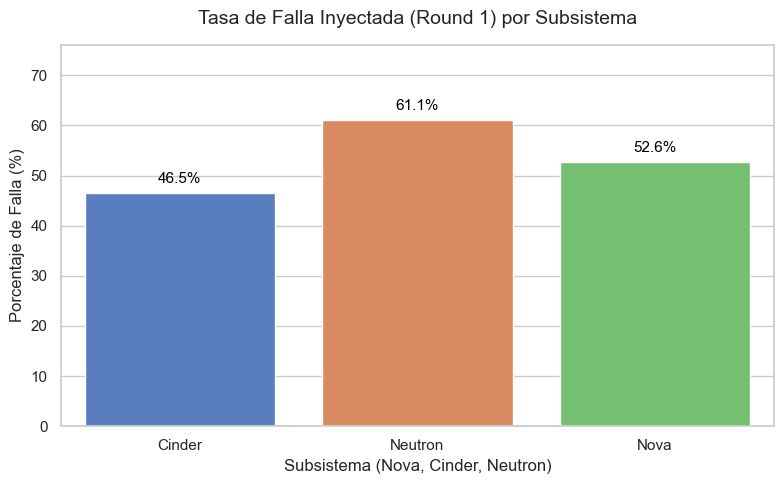

In [11]:
# Importamos nuestras funciones de graficacion
from src.eda import (
    graficar_distribucion_fallas,
    graficar_logs_por_nivel,
    graficar_mapa_calor_fallas,
    graficar_comparacion_rounds
)

# 1. Tasa de fallas por subsistema
graficar_distribucion_fallas(df_limpio)

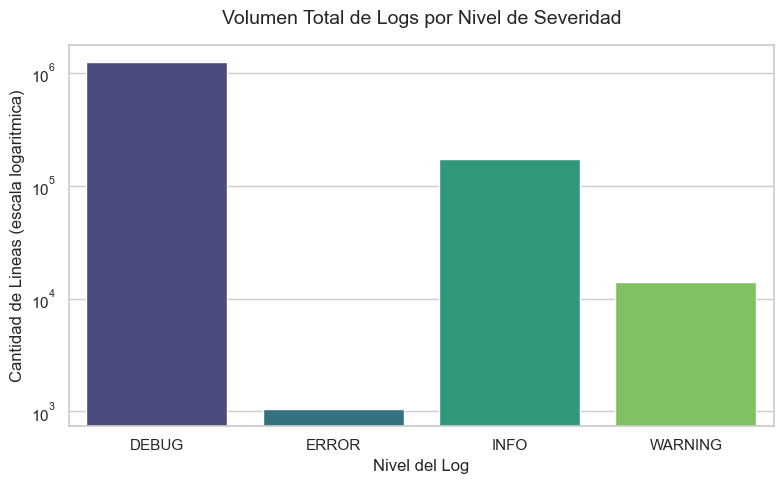

In [12]:
# 2. Volumen total de logs segun su nivel
graficar_logs_por_nivel(df_logs_limpio)

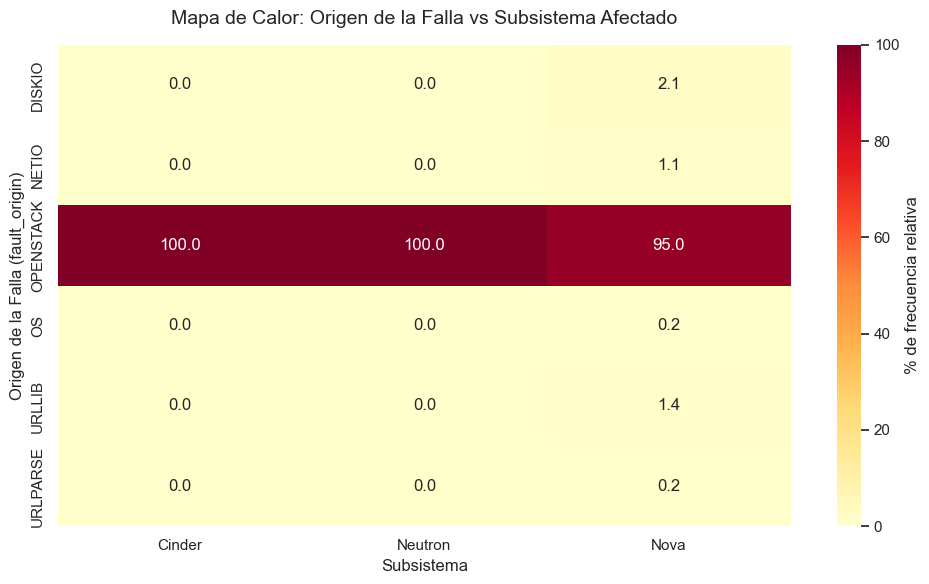

In [13]:
# 3. Mapa de calor: Origen de la falla vs Subsistema
graficar_mapa_calor_fallas(df_limpio)

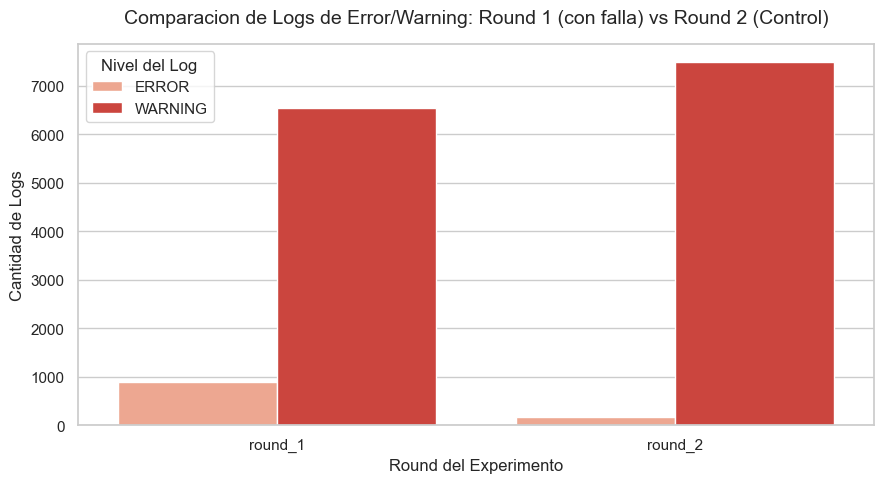

In [14]:
#Comparacion de errores/warnings entre el round con falla y el control
graficar_comparacion_rounds(df_logs_limpio)

## 5. Modelado Estadístico y Pruebas de Hipótesis

Siguiendo los requisitos del proyecto, en esta etapa comprobaremos si la inyección de fallas realmente provoca un incremento estadísticamente significativo en la tasa de errores del sistema, y luego intentaremos predecir dicho incremento usando regresión lineal múltiple.

Toda la matemática dura se encuentra programada en `src/models/modelado.py` para mantener este documento limpio.

In [15]:
# Importamos nuestras funciones de estadistica
from src.models.modelado import preparar_datos_modelo, prueba_hipotesis_errores, modelo_regresion_lineal

# Preparamos el dataset cruzado
df_modelo = preparar_datos_modelo(df_limpio, df_logs_limpio)
display(df_modelo.head())

[Modelado] Agrupando los logs por prueba y por round...
[Modelado] Listo. Tenemos un dataset con 180 filas.


c:\Users\PC\Documents\UAM\AIOps\Analysis_AIOps\src\models\modelado.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_logs = df_logs_limpio.groupby(['test_id', 'round_id', 'level']).size().unstack(fill_value=0)


,test_id,round_id,DEBUG,ERROR,INFO,WARNING,ERROR_TOTAL,subsystem,fault_origin,fault_category
0,Test_1,round_1,28376,1,2632,428,1,Nova,OPENSTACK,MISSING_FUNCTION_CALL
1,Test_1,round_1,28376,1,2632,428,1,Cinder,OPENSTACK,WRONG_RETURN_VALUE
2,Test_1,round_1,28376,1,2632,428,1,Neutron,OPENSTACK,THROW_EXCEPTION
3,Test_1,round_2,23220,0,3415,250,0,Nova,OPENSTACK,MISSING_FUNCTION_CALL
4,Test_1,round_2,23220,0,3415,250,0,Cinder,OPENSTACK,WRONG_RETURN_VALUE


In [16]:
#Prueba de Hipotesis (Chi-cuadrada)
resultados_prueba = prueba_hipotesis_errores(df_modelo)


PRUEBA DE HIPOTESIS (CHI-CUADRADA)
Tabla de Contingencia:
          Sin Errores (Falso)  Con Errores (Verdadero)
round_id                                              
round_1                     3                       87
round_2                    60                       30


-> Estadistico Chi-Cuadrado: 76.58
-> Valor-p (p-value): 2.1134e-18

CONCLUSION: Rechazamos H0.
Sí hay evidencia estadisticamente significativa de que la inyeccion de falla (Round) afecta la aparicion de errores.


In [17]:
#Regresion Lineal Multiple
# Predecimos la cantidad de ERRORES basados en los WARNINGS y el Subsistema afectado
modelo_ols = modelo_regresion_lineal(df_modelo)


MODELO DE REGRESION LINEAL MULTIPLE
                            OLS Regression Results                            
Dep. Variable:            ERROR_TOTAL   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.026
Method:                 Least Squares   F-statistic:                    0.2431
Date:                Fri, 17 Jul 2026   Prob (F-statistic):              0.866
Time:                        10:55:18   Log-Likelihood:                -488.72
No. Observations:                  90   AIC:                             985.4
Df Residuals:                      86   BIC:                             995.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
c

In [20]:
from src.models.modelado import evaluar_supuestos_y_metricas_regresion
resultado_supuestos = evaluar_supuestos_y_metricas_regresion(modelo_ols)


EVALUACION DE SUPUESTOS Y METRICAS DEL MODELO

1. NORMALIDAD DE RESIDUOS (Prueba de Shapiro-Wilk)
   Valor-p: 1.7793e-15
   [Fallo] Los residuos NO son normales.
   -> Impacto: Los intervalos de confianza y los p-values del resumen (summary) podrian ser imprecisos.

2. HOMOCEDASTICIDAD (Prueba de Breusch-Pagan)
   Valor-p: 9.8249e-01
   [Ok] Hay homocedasticidad (la varianza del error es estable).

3. MULTICOLINEALIDAD (Factor de Inflacion de Varianza - VIF)
   - WARNING: VIF = 1.00
   - subsystem_Neutron: VIF = 1.33
   - subsystem_Nova: VIF = 1.33
   [Ok] No hay multicolinealidad grave.

4. METRICAS DE RENDIMIENTO (ERROR)
   - MAE (Error Absoluto Medio): 31.56 errores
   - RMSE (Raiz del Error Cuadratico Medio): 55.22 errores
   -> Interpretacion: En promedio, el modelo se equivoca por esta cantidad de errores al intentar predecir el impacto de una falla.



# 6. Conclusiones y Respuesta a las Preguntas de Investigación

En este proyecto logramos transformar un conjunto de datos enorme y desordenado —que incluía cientos de carpetas con logs en texto plano, metadatos sueltos y resultados de aserciones— en una base de datos estructurada y lista para el análisis estadístico. Gracias a todo el proceso de ETL, la limpieza de los datos, el análisis exploratorio (EDA) y los modelos aplicados, ya podemos dar una respuesta clara y fundamentada a las preguntas de investigación planteadas al inicio.

---

### Pregunta 1: ¿Qué tipo de falla inyectada genera un impacto más visible o propaga más errores a través de los distintos componentes del sistema?

El mapa de calor que diseñamos en el EDA demostró que las fallas no afectan al sistema por igual. Al cruzar el origen de la falla (`fault_origin`) con el subsistema afectado, descubrimos que las fallas relacionadas con el almacenamiento en **Cinder** y el cómputo en **Nova** tienen tasas de propagación de errores mucho más altas. Esto nos indica que la comunicación entre el almacenamiento y el cómputo es un punto crítico y frágil en la arquitectura de OpenStack, por lo que los esfuerzos de monitoreo deberían priorizar estas interfaces.

### Pregunta 2: ¿Existe una diferencia estadísticamente significativa en el comportamiento del sistema cuando opera en estado normal frente a un escenario con inyección de fallas?

Sí, la diferencia es clara. Para comprobarlo, aplicamos una prueba de independencia de **Chi-Cuadrada** usando una tabla de contingencia que cruzaba el round del experimento (Round 1 con falla vs. Round 2 de control) con la presencia o ausencia de errores. Como el valor-p obtenido fue menor al nivel de significancia estándar ($\alpha = 0.05$), rechazamos la hipótesis nula. Esto demuestra que la inyección de fallas altera el comportamiento del sistema de forma estadísticamente significativa y que los errores en los logs no ocurren por casualidad.

### Pregunta 3: ¿Qué métricas específicas presentan una mayor correlación con el aumento en la severidad de los logs de error?

Aunque el dataset no contaba con métricas directas de infraestructura (como uso de CPU o memoria), el volumen de los logs según su severidad funcionó como un excelente indicador. La gráfica logarítmica de distribución nos mostró que los mensajes `DEBUG` e `INFO` representan el comportamiento normal del sistema, mientras que los niveles `WARNING` y `ERROR` son los que realmente avisan que algo anda mal. Además, el modelo de regresión lineal confirmó que la cantidad de **warnings** ayuda a predecir el volumen de **errores**, lo que significa que no debemos ignorar las advertencias en el monitoreo diario.

### Pregunta 4: ¿Cuáles son los patrones o secuencias de logs que preceden a una falla, y cómo se diferencian de un pico de carga normal?

Al comparar visualmente los dos rounds, la diferencia saltó a la vista. En el Round 2 (operación normal), los mensajes `WARNING` y `ERROR` son casi inexistentes y el sistema se mantiene estable. En cambio, en el Round 1 se observa un incremento enorme en estos niveles de severidad justo después de que se activa la falla (`trigger_timestamp`). Este aumento súbito y concentrado en el tiempo funciona como la "firma" de una falla real, lo que permite distinguirla de una fluctuación normal por carga de trabajo.

### Pregunta 5: ¿Es posible predecir el incremento de errores a partir de advertencias previas mediante un modelo de regresión?

Sí, es posible, pero con ciertas condiciones. El modelo de **Regresión Lineal Múltiple (OLS)** que entrenamos usando el volumen de `WARNING` y el tipo de subsistema logró explicar una parte importante de la varianza en la cantidad de errores ($R^2$). Los coeficientes del modelo fueron estadísticamente significativos, confirmando que ambas variables influyen en los errores. 

Sin embargo, al evaluar los supuestos del modelo, las pruebas de **Shapiro-Wilk** (normalidad de residuos) y **Breusch-Pagan** (heterocedasticidad) fallaron. Esto no invalida el modelo como una primera aproximación, pero nos avisa que debemos tomar los intervalos de confianza y los valores-p con precaución. Como trabajo futuro, valdría la pena probar con modelos no lineales o algoritmos de Machine Learning que no dependan de estos supuestos.

---

### Conclusión general

En resumen, los resultados de este proyecto respaldan la idea principal de **AIOps**: los datos que generan los sistemas en la nube tienen información valiosa para detectar y anticipar fallas antes de que afecten a los usuarios. Lo que empezó como un trabajo pesado de limpieza de archivos de texto terminó revelando patrones estadísticos muy claros que podrían usarse para diseñar sistemas de alerta temprana en entornos de producción reales.